(3043, 6)
count    3043.000000
mean       92.088071
std       106.493169
min         1.000000
25%        34.000000
50%        65.000000
75%       113.000000
max      2197.000000
Name: text, dtype: float64
count    3043.000000
mean       20.887282
std       141.176139
min         0.000000
25%         0.000000
50%         1.000000
75%         8.000000
max      5360.000000
Name: like_count, dtype: float64
text
Tama                                                                                               10
❤❤❤                                                                                                 5
💚💚💚                                                                                                 4
😂😂😂😂😂                                                                                               4
​@@JuanManuel-t9kBugok kaya nagkaroon ng West Philippines Sea sa google dahil kay marcoleta 🥰😘😍     4
🤔                                                                              

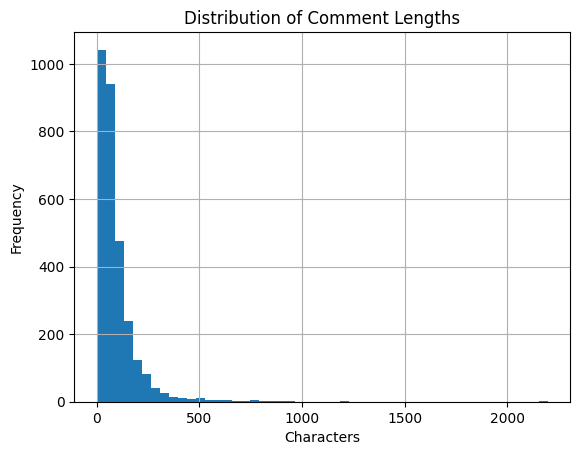

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Topic 0:
['sa', 'senators', 'people', 'mga', 'tama', 'senate', 'impeachment', 'kayo', 'ang', 'po']
---
Topic 1:
['philippines', 'job', 'duterte', 'si', 'senate', 'hontiveros', 'time', 'philhealth', 'public', 'good']
---
Topic 2:
['ni', 'yan', 'hindi', 'pa', 'mo', 'mga', 'ng', 'sa', 'ang', 'na']
---
Topic 3:
['hindi', 'yan', 'lang', 'mo', 'ka', 'mga', 'na', 'ng', 'ang', 'sa']
---
Topic 4:
['chiz', 'po', 'bless', 'god', 'sir', 'si', 'ka', 'senator', 'marcoleta', 'sen']
---


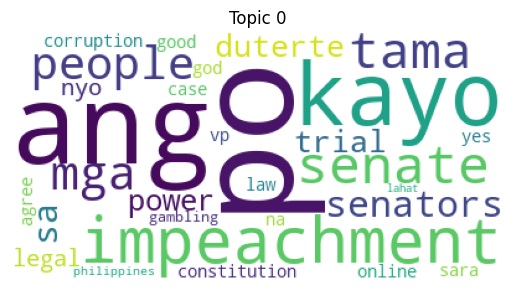

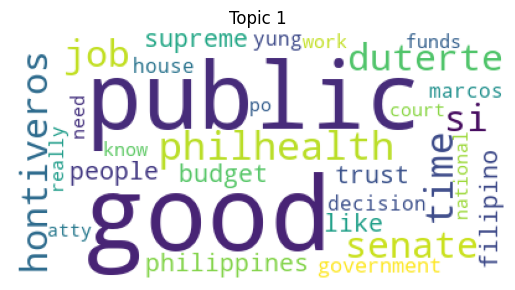

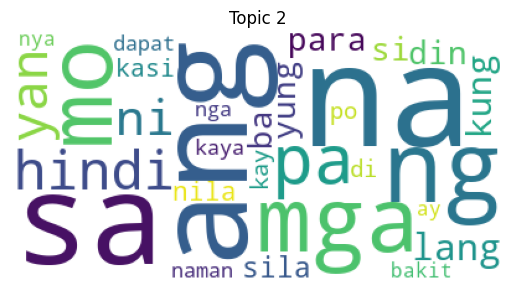

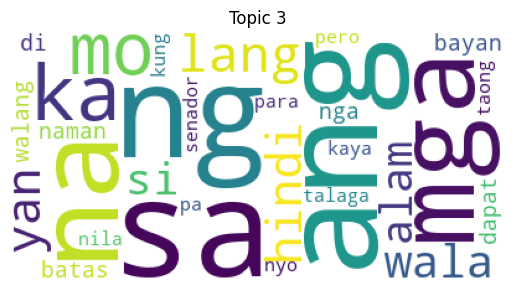

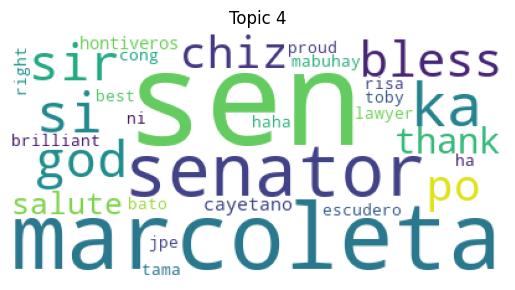

In [8]:
# Load Data
import pandas as pd

# base sheet of scraped comments
comments = pd.read_excel("method-1-youtube/scripts/youtube_comments.xlsx", sheet_name="youtube_base")
print(comments.shape)
comments.head()

# Exploratory Data Analysis
# basic stats
print(comments['text'].str.len().describe())
print(comments['like_count'].describe())

# Most common comments
print(comments['text'].value_counts().head(10))

# distribution of comment lengths
import matplotlib.pyplot as plt
comments['text'].str.len().hist(bins=50)
plt.title("Distribution of Comment Lengths")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

# nlp Preprocessing
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+', '', text)      # remove links
    text = re.sub(r'[^a-z\s]', '', text)     # keep only letters
    words = [w for w in text.split() if w not in stop_words]
    return " ".join(words)

comments['processed_text'] = comments['text'].apply(clean_text)
comments[['text','processed_text']].head()

# Topic Modeling
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# vectorize
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
X = vectorizer.fit_transform(comments['processed_text'])

# fit LDA
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X)

# print top words per topic
terms = vectorizer.get_feature_names_out()
for idx, topic in enumerate(lda.components_):
    print(f"Topic {idx}:")
    print([terms[i] for i in topic.argsort()[-10:]])
    print("---")

# visualize topics with word clouds
from wordcloud import WordCloud

for idx, topic in enumerate(lda.components_):
    plt.figure()
    plt.imshow(WordCloud(background_color='white').fit_words({terms[i]: topic[i] for i in topic.argsort()[-30:]}))
    plt.axis("off")
    plt.title(f"Topic {idx}")
    plt.show()

# Assign Topics to Comments
comment_topics = lda.transform(X).argmax(axis=1)
comments['topic'] = comment_topics
comments[['text','topic']].head(20)

# Save results
comments.to_excel("youtube_comments_with_topics.xlsx", index=False)


## Exploratory data Analysis
- Number of comments: 3043
- distribution of lengths is skewed (most under 200 characters)
- Most common words include political names (Risa (hontiveros), Raffy (tulfo), etc.)

## Topic Modeling Results
- Topic 0: Support for Risa Hontiveros
- Topic 1: Criticism & comparisons with other senators
- Topic 2: Conversational fillers in tagalog
- Topic 3: political commentary in general
- Topic 4: Mentions of senators (Chiz, Marcoleta, etc.)


In [13]:
import os
os.path.exists("youtube_comments_with_topics.xlsx")

True